###  Supplementary Figure 1: Arm B during (23rd Jan 2025)

In [1]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [2]:

import marsilea as ma
import marsilea.plotter as mp

In [3]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [6]:
## read in data

arm = 'ArmB_2024/'
log_data = 'CN_during/' 

data_path = arm+log_data

count_matrix =  np.array(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None)) 

In [7]:
cluster_asgn =  np.array(pd.read_csv(os.path.join(data_path+'cluster_asgnments_kmeans_nolog.csv'), header=None,index_col=None))
X_2d_1 =  np.array(pd.read_csv(os.path.join(data_path+'X_2d_tsne_nolog.csv'), header=None,index_col=None)) 



In [8]:
print(count_matrix.shape)
print(cluster_asgn.shape)
print(X_2d_1.shape)


(328763, 31)
(328763, 1)
(328763, 2)


In [9]:
unique, counts = np.unique(cluster_asgn, return_counts=True)
print('unique',str(unique))
print(counts)

unique [ 1  4  8  9 11 12 13 14 15 16 17 19 20 22 23 24]
[ 55444      4      2      5 121208 151310      3      1    643     16
     97      5      9      4      9      3]


In [10]:
cluster_asgn1 = cluster_asgn.flatten()

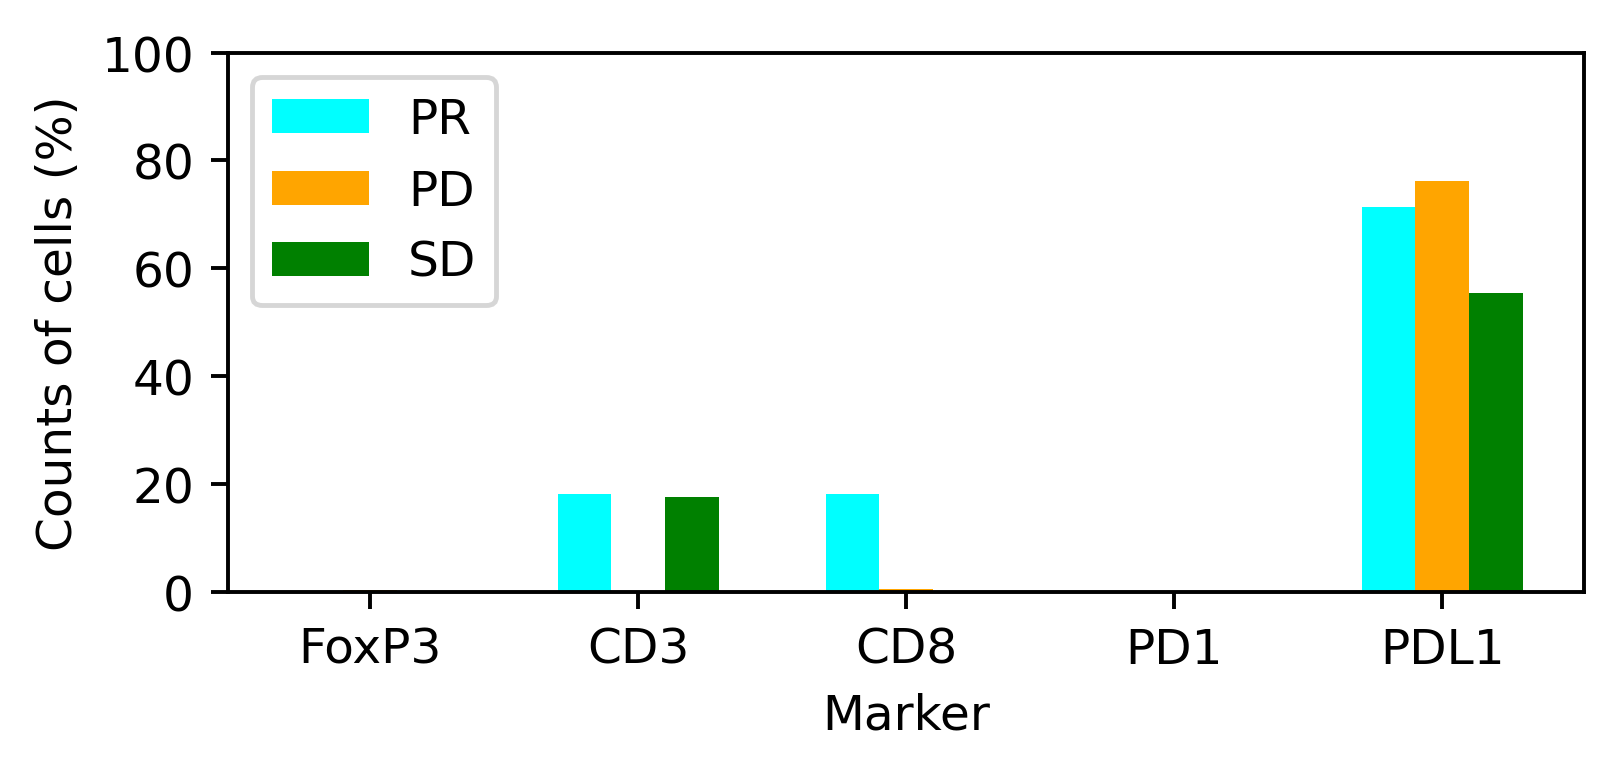

In [206]:
# importing package 
import matplotlib.pyplot as plt 
import numpy as np 

plt.figure(figsize=(5,2), dpi=350)
# create data 
x = np.arange(5) 
y1 = pr_list
y2 = pd_list
y3 = sd_list
width = 0.2
  
# plot data in grouped manner of bar type 
plt.bar(x-0.2, y1, width, color='cyan') 
plt.bar(x, y2, width, color='orange') 
plt.bar(x+0.2, y3, width, color='green') 
plt.xticks(x, y_marker) 
plt.xlabel("Marker") 
plt.ylabel("Counts of cells (%)") 
plt.legend(["PR", "PD", "SD"]) 
plt.ylim(0,100)
plt.show() 

In [208]:
unique_ts, counts_ts = np.unique(count_matrix[:,8], return_counts=True)
print(unique_ts)
len(unique_ts)

[ 52.  56.  65.  70.  74.  75.  77.  78.  87.  95. 106. 107. 112. 113.
 125. 131.]


16

(0.0, 13.0)

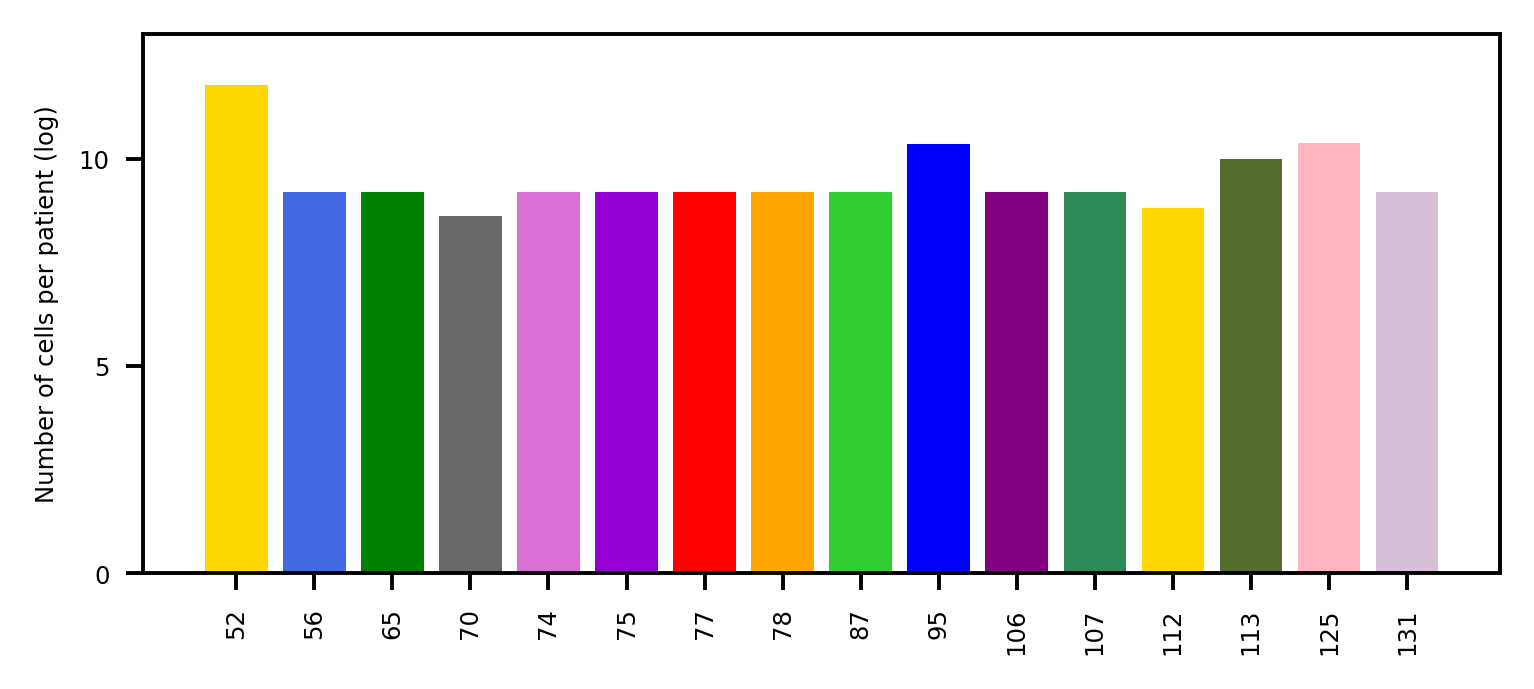

In [209]:
## plot the sizes
N= len(unique_ts)
ind = np.arange(N)
plt.figure(figsize=(5,2), dpi=350)
x=np.arange(N) #[0,1,2,3,4]

y=np.log(counts_ts)#/tot_cells)

for h in range(N):
    plt.bar(x[h], y[h], color=colours_30[h+1])
    
plt.xticks(ind, np.int64(unique_ts),rotation = 90,fontsize=5)
plt.yticks(fontsize=5)
plt.ylabel('Number of cells per patient (log)',fontsize=5)
plt.ylim(0,13)

#plt.savefig('SVM_patient_Lung2_testsize_nolog_pdl1.png', dpi=400, transparent=True)
#plt.show()

In [137]:
print(y1)
print(y2)
print(y3)

[0.0021776597002295876, 0.0021776597002295876, 0.0046664136433491165, 0.0, 45.13884136060178]
[0.0017733797958839855, 0.0, 0.0017733797958839855, 0.0, 23.64890626801089]
[0.013695056736663623, 0.004565018912221208, 0.025433676796661014, 0.0, 42.82835528890048]


In [94]:
counts_ts

array([131197,  21606,  15175,   5504,  59999,  21015,  59992,  48817,
        23217,  31120,  25865,  30499,   6797,  21640,  32342,  52780])

In [127]:

from sklearn.metrics.pairwise import euclidean_distances, paired_distances

X = [[0, 1],[10,11]]
#Y = [[0, 11]]
paired_distances(X, X)


array([0., 0.])

In [126]:
euclidean_distances(X,X)

array([[ 0., 10.],
       [10.,  0.]])

In [129]:
Y=[[ 5770.0  ,  424.5],
 [ 5755.0   , 426.5],
 [ 5746.0    ,436. ]]

In [130]:
paired_distances(Y, Y)

array([0., 0., 0.])

In [131]:
euclidean_distances(Y,Y)

array([[ 0.        , 15.13274595, 26.61296676],
       [15.13274595,  0.        , 13.08625233],
       [26.61296676, 13.08625233,  0.        ]])

In [134]:
yy = np.array(Y)

In [136]:
np.transpose(np.vstack([yy[:,0],yy[:,1]]))


array([[5770. ,  424.5],
       [5755. ,  426.5],
       [5746. ,  436. ]])

#### scanpy trial

In [44]:
import scipy 
import os
import scipy.io as sio
import scanpy as sc

In [45]:
#anno = sc.read(pd.read_csv(os.path.join(data_path+'count_data_combined.csv'), header=None,index_col=None))
#adata.obs['data'] = anno  # categorical annotation of type pandas.Categorical
#adata = sc.AnnData(count_matrix)
df = count_matrix[:,21:26]
adata = sc.AnnData(df)


adata.obs_names = [f"Cell_{i:d}" for i in range(adata.n_obs)]
adata.var_names = [f"Gene_{i:d}" for i in range(adata.n_vars)]

adata.obs["louvain"] = cluster_asgn1
print(adata.var_names[:10])

Index(['Gene_0', 'Gene_1', 'Gene_2', 'Gene_3', 'Gene_4'], dtype='object')


In [46]:
adata

AnnData object with n_obs × n_vars = 328763 × 5
    obs: 'louvain'

In [107]:
y_marker = ['FoxP3','CD3',  'CD8', 'PD1','PDL1' ]
#adata.var_names = y_marker #[f"Gene_{i:d}" for i in range(adata.n_vars)]           
cell_markers = {
    "T reg cells": ["FoXP3"],
    "CD3+ T cells": ["CD3"],
    "CD8 T cells": ["CD8"],
    "PD-1 cells": ["PD-1"],
    "PD-L1 cells": ["PD-L1"],
}

cells, markers = [], []
for c, ms in cell_markers.items():
    cells += [c] * len(ms)
    markers += ms

uni_cells = list(cell_markers.keys())
cell_colors = [
    "#568564",
    "#DC6B19",
    "#F72464",
    "#005585",
    "#9876DE",
    "#405559",
    "#58DADA",
    "#F85959",
]
cmapper = dict(zip(uni_cells, cell_colors))

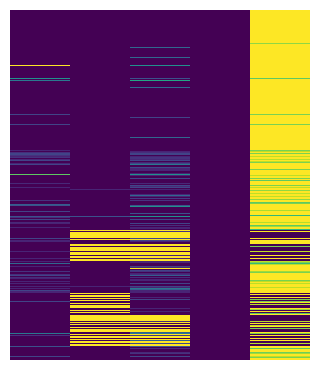

In [108]:
exp = adata[:, 0:5].X.toarray()

m = ma.Heatmap(exp, cmap="viridis", height=3.5, width=3)
m.render()

In [109]:
agg = sc.get.aggregate(adata[:, 0:5], by="louvain", func=["mean", "count_nonzero"])
agg.obs["cell_counts"] = adata.obs["louvain"].value_counts()
agg

AnnData object with n_obs × n_vars = 16 × 5
    obs: 'louvain', 'cell_counts'
    layers: 'mean', 'count_nonzero'

In [110]:
agg_exp = agg.layers["mean"]
agg_count = agg.layers["count_nonzero"]
agg_cell_counts = adata.obs["louvain"].value_counts().to_numpy()

In [111]:
agg_cell_counts

array([151310, 121208,  55444,    643,     97,     16,      9,      9,
            5,      5,      4,      4,      3,      3,      2,      1])

In [112]:
adata.obs["louvain"].value_counts()

louvain
12    151310
11    121208
1      55444
15       643
17        97
16        16
23         9
20         9
19         5
9          5
22         4
4          4
13         3
24         3
8          2
14         1
Name: count, dtype: int64

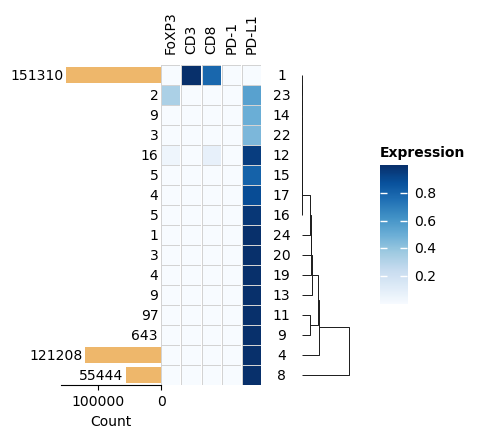

In [113]:
h, w = agg_exp.shape

m = ma.Heatmap(
    agg_exp,
    height=h / 5,
    width=w / 5,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)

m.add_right(mp.Labels(agg.obs["louvain"], align="center"), pad=0.1)
m.add_top(mp.Labels(markers), pad=0.1)

m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.add_left(mp.Numbers(agg_cell_counts, color="#EEB76B", label="Count"))
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

In [114]:
uni_cells

['T reg cells', 'CD3+ T cells', 'CD8 T cells', 'PD-1 cells', 'PD-L1 cells']

In [115]:
### collapse clusters and update louvain entry

In [116]:
cluster_asgn2 = np.zeros(cluster_asgn1.shape)

In [117]:
## pd-l1 high
row = np.where(cluster_asgn1==16)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==24)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==20)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==19)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==13)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==11)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==9)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==4)
cluster_asgn2[row]=np.int64(100)
row = np.where(cluster_asgn1==8)
cluster_asgn2[row]=np.int64(100)

#pdl1 medium
row = np.where(cluster_asgn1==15)
cluster_asgn2[row]=np.int64(200)
row = np.where(cluster_asgn1==17)
cluster_asgn2[row]=np.int64(200)

#pdl1 low
row = np.where(cluster_asgn1==14)
cluster_asgn2[row]=np.int64(300)
row = np.where(cluster_asgn1==22)
cluster_asgn2[row]=np.int64(300)


#cd3/8
row = np.where(cluster_asgn1==1)
cluster_asgn2[row]=np.int64(400)

#fox pdl1
row = np.where(cluster_asgn1==23)
cluster_asgn2[row]=np.int64(500)

#fox cd8 pdl1
row = np.where(cluster_asgn1==12)
cluster_asgn2[row]=np.int64(600)
cluster_asgn2 = cluster_asgn2 -1

In [118]:
cluster_asgn2 = np.int64(cluster_asgn2/100)

In [119]:
adata.obs["louvain1"] = cluster_asgn2

In [120]:
agg1 = sc.get.aggregate(adata[:, 0:5], by="louvain1", func=["mean", "count_nonzero"])
agg1.obs["cell_counts"] = adata.obs["louvain1"].value_counts()
agg1

AnnData object with n_obs × n_vars = 6 × 5
    obs: 'louvain1', 'cell_counts'
    layers: 'mean', 'count_nonzero'

In [121]:
agg_exp1 = agg1.layers["mean"]
agg_count1 = agg1.layers["count_nonzero"]
#agg_cell_counts1 = agg1.obs["cell_counts"].to_numpy()

In [122]:
agg_cell_counts1= adata.obs["louvain1"].value_counts().to_numpy()

In [123]:
agg_cell_counts1

array([151310, 121255,  55444,    740,      9,      5])

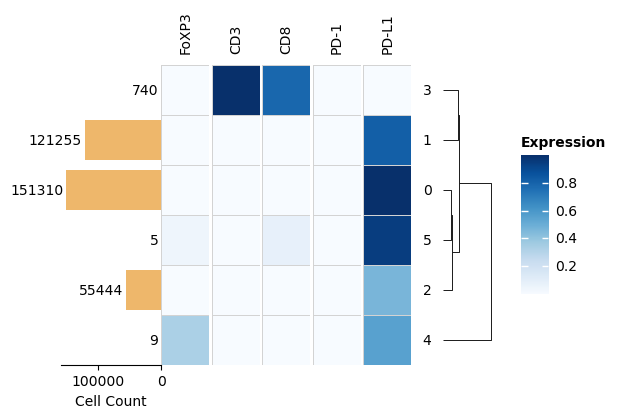

In [125]:
h, w = agg_exp1.shape

m = ma.Heatmap(
    agg_exp1,
    height=h / 2,
    width=w / 2,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)
m.add_right(mp.Labels(agg1.obs["louvain1"], align="center"), pad=0.1)


m.add_top(mp.Labels(markers), pad=0.1)

m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))

'''
m.add_left(mp.Numbers(agg_cell_counts1, color="#EEB76B", label="Cell Count"))

m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

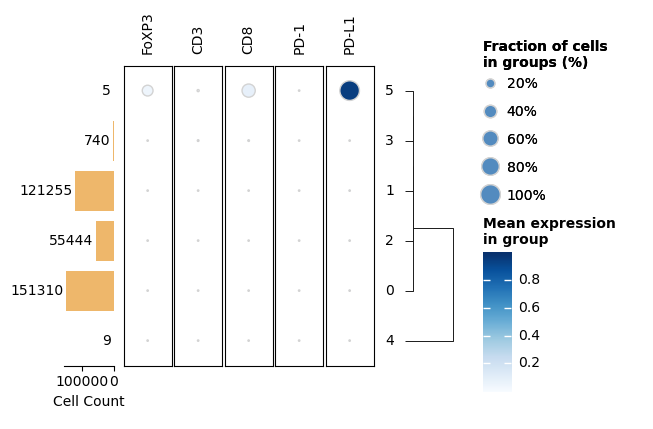

In [126]:
size = agg_count1 / agg_cell_counts1[:, np.newaxis]
m = ma.SizedHeatmap(
    size=size,
    color=agg_exp1,
    cluster_data=size,
    height=h / 2,
    width=w / 2,
    edgecolor="lightgray",
    cmap="Blues",
    size_legend_kws=dict(
        colors="#538bbf",
        title="Fraction of cells\nin groups (%)",
        labels=["20%", "40%", "60%", "80%", "100%"],
        show_at=[0.2, 0.4, 0.6, 0.8, 1.0],
    ),
    color_legend_kws=dict(title="Mean expression\nin group"),
)


m.add_top(mp.Labels(markers), pad=0.1)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.group_cols(cells, order=uni_cells)

m.add_right(mp.Labels(agg1.obs["louvain1"], align="center"), pad=0.1)

m.add_left(
    mp.Numbers(agg_cell_counts1, color="#EEB76B", label="Cell Count"), size=0.5, pad=0.1
)
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

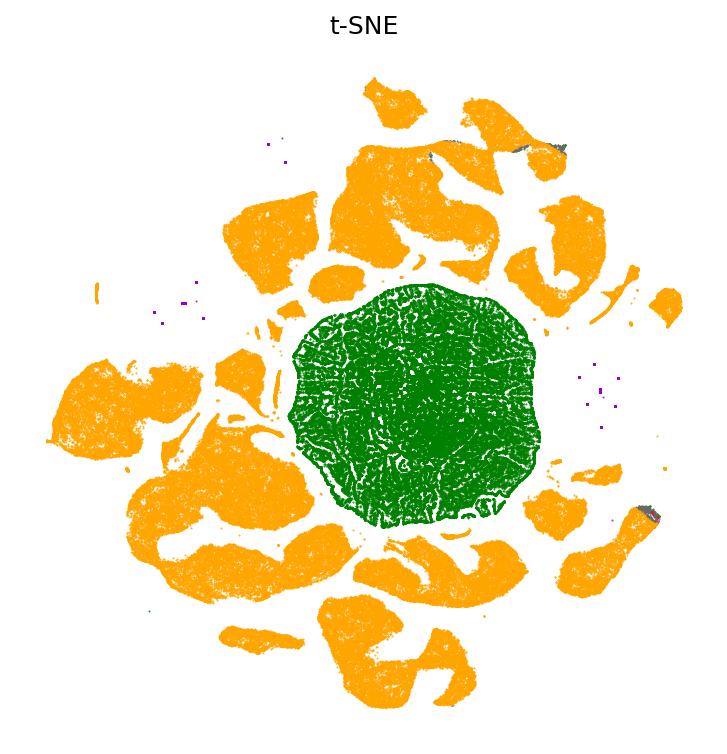

In [127]:
#t-SNE plots
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
plt.figure(figsize=(6,6),dpi=150)
plt.axis('off')
#colors = 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple'
for i,  label in zip(target_ids,  unique1):
    #print(label)
    c=colours_30[i+3] #cm.colors[i]
    plt.scatter(X_2d_1[ cluster_asgn2==(i), 0], X_2d_1[ cluster_asgn2==(i), 1], color=c,label=label,s=1,linewidths=0,alpha=0.8)
#plt.legend(loc=3)
plt.title('t-SNE')
plt.show()


0
green
1
dimgray
2
orchid
3
darkviolet
4
red
5
orange


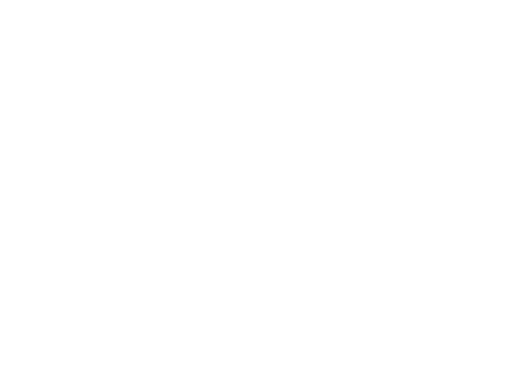

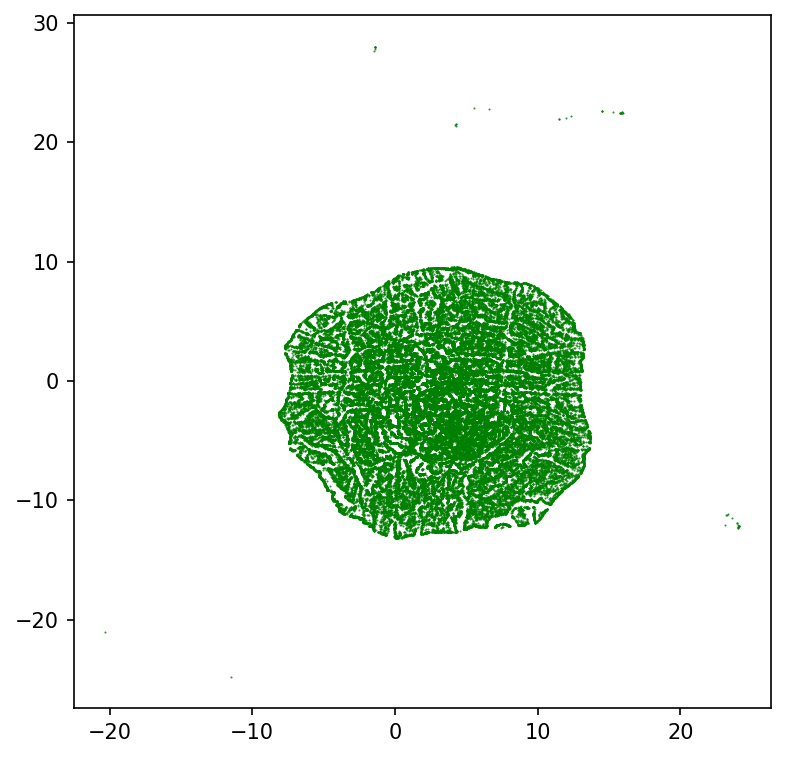

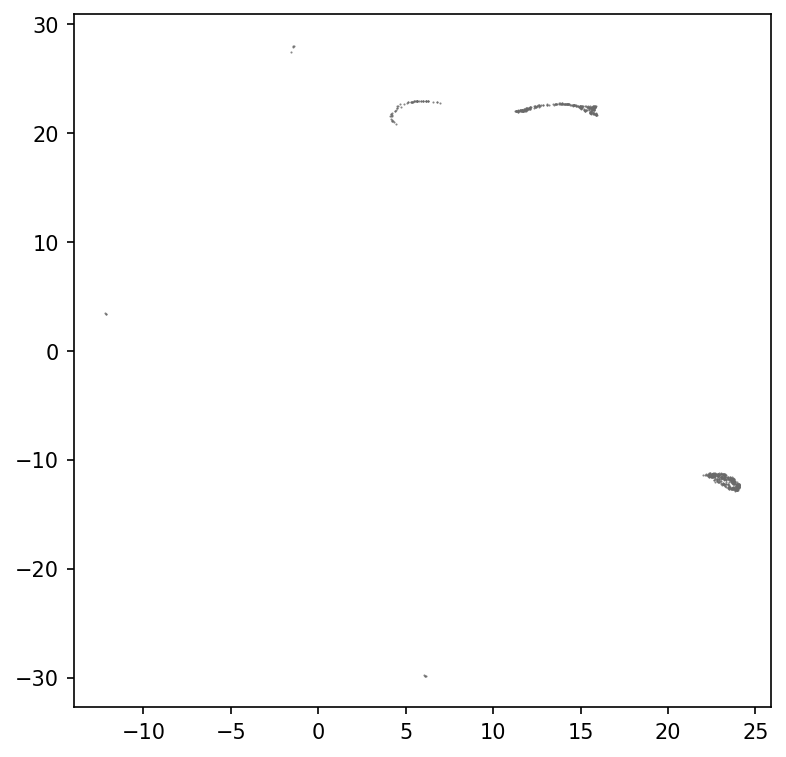

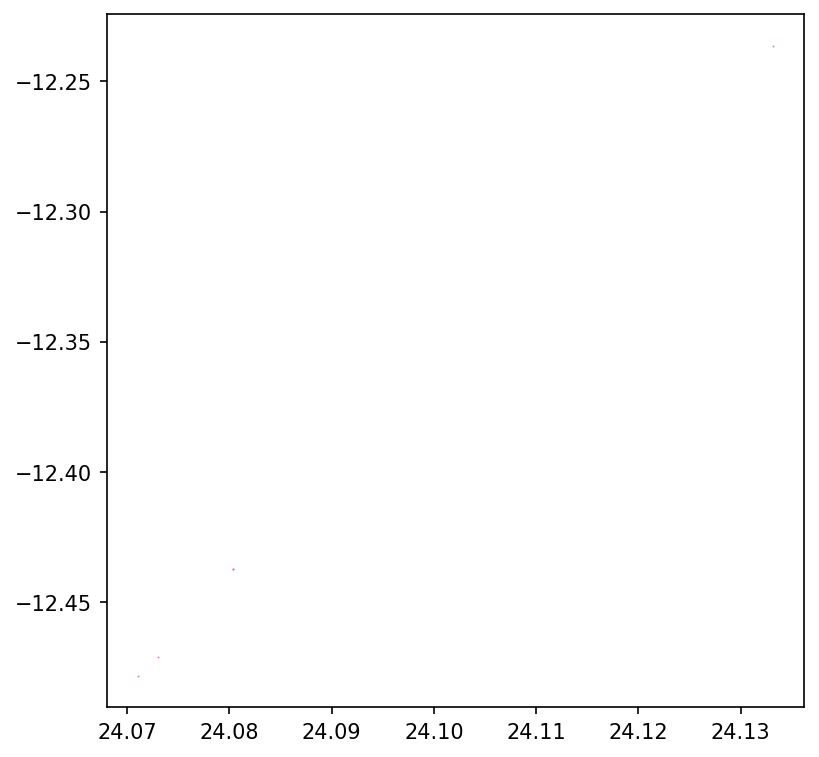

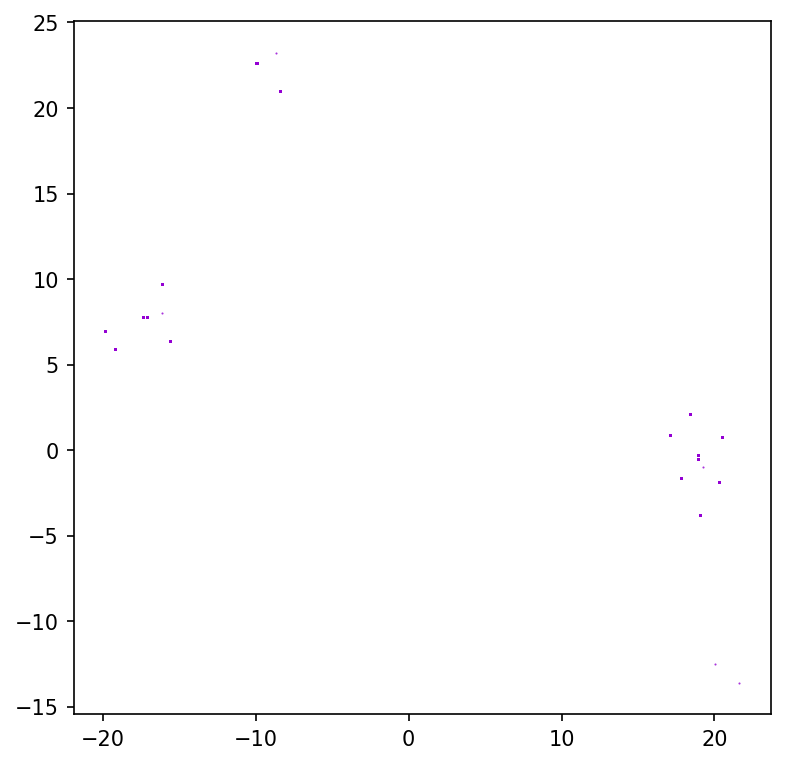

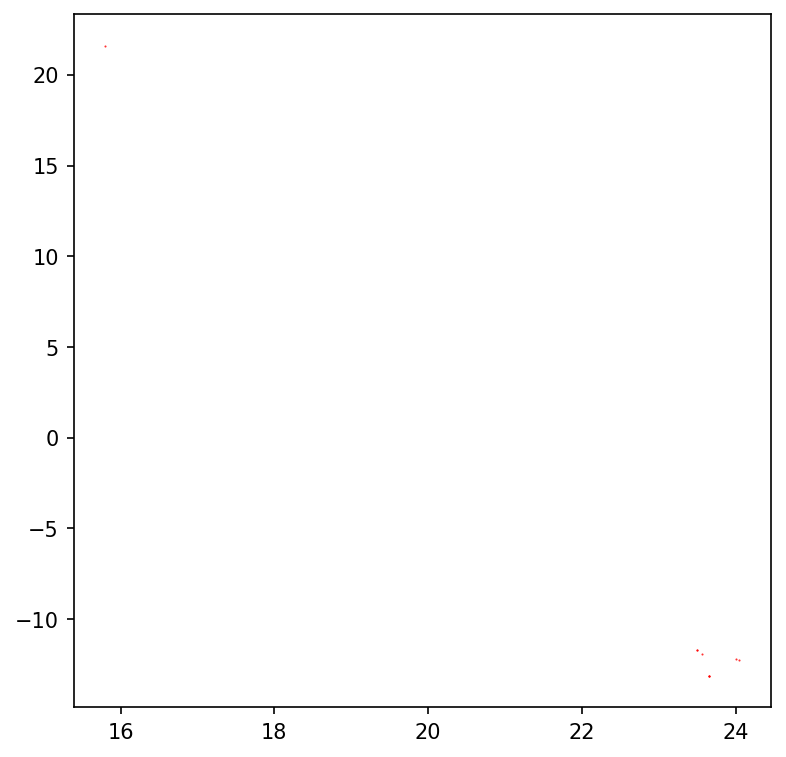

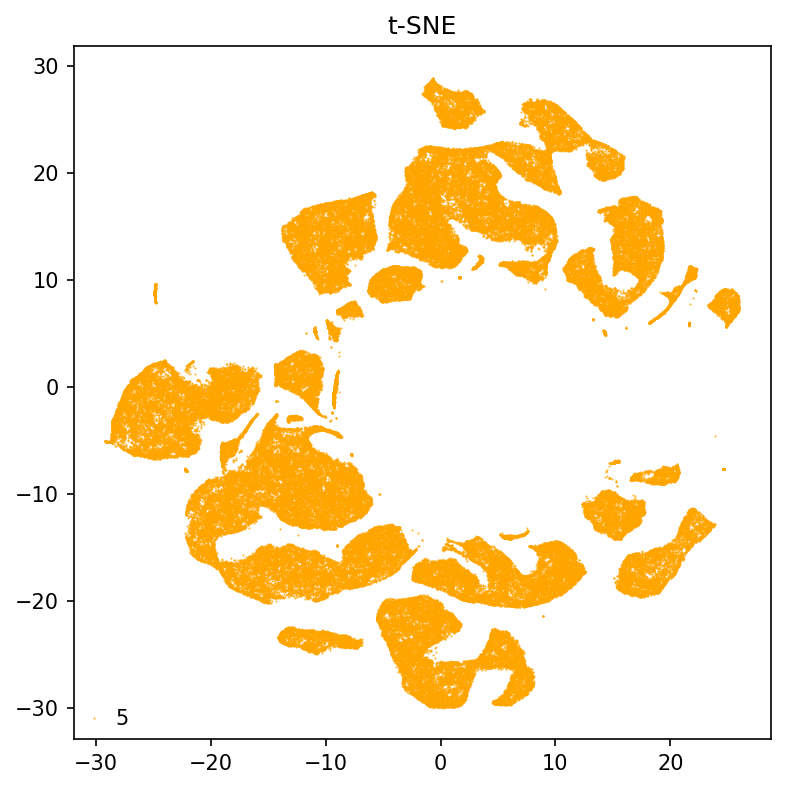

In [147]:
#t-SNE plots
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
#plt.figure(figsize=(6,6),dpi=150)
plt.axis('off')
#colors = 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple'
for i,  label in zip(target_ids,  unique1):
    print(label)
    plt.figure(figsize=(6,6),dpi=150)
    c=colours_30[i+3] #cm.colors[i]
    print(c)
    plt.scatter(X_2d_1[ cluster_asgn2==(i), 0], X_2d_1[ cluster_asgn2==(i), 1], color=c,label=label,s=1,linewidths=0,alpha=0.8)
plt.legend(loc=3)
plt.title('t-SNE')
plt.show()


In [128]:
count1

array([121255,    740,      5,  55444,      9, 151310])

In [129]:
### create the names for the clusters

In [130]:
np.shape(cluster_asgn2)

(328763,)

In [148]:
unique1, count1 = np.unique(cluster_asgn2, return_counts=True)
target_ids = range(len(unique1))
cell_classes = ['PD-L1+ high','PD-L1+ medium','PD-L1+ low','CD3+ CD8+','FoxP3+ PD-L1+','FoxP3+ CD8+ PD-L1+']
#louvain_names = np.zeros(np.shape(cluster_asgn2))
listOfStrings = [" "] * 328763
col_len = []
for i,  label in zip(target_ids,  unique1):
    print(label)
    s= np.array(np.where(cluster_asgn2==label)).flatten()
    print(s.shape)
    print(s)
    col_len.append(np.int64(s.shape))
    #print(s)
    
    for j in range(len(s)):
        listOfStrings[s[j]]=cell_classes[label]
    

0
(121255,)
[     1      2      3 ... 326113 327748 328507]
1
(740,)
[  1632   1641   2014   2067   2780   2870   6209   8100   9012   9020
  12207  12277  12868  13585  15614  15806  15807  15808  19032  19133
  19573  20576  22227  23505  26879  33653  35595  35600  40011  40089
  41782  42316  43871  43925  49793  49979  50498  52268  53534  53812
  54615  55878  58378  60303  67165  68214  71139  71154  71652  71720
  72453  73527  74721  77150  78009  81049  81114  81945  82826  83914
  85974  87171  87993  89106  90069  91046  91642  91691  91759  92654
  92700  95281  96249  96290  97243 100941 104405 105502 107268 107319
 107431 109018 109023 109230 109327 109761 110175 110835 111440 111595
 112196 112323 114604 115665 115902 115936 117483 117682 117749 117791
 118520 119032 119813 122208 125793 126575 126590 127416 129568 129833
 130381 130382 131639 132812 133279 133336 135859 136029 136354 136369
 136556 136560 136568 137010 137011 137075 140059 140834 145862 146326
 147122 

In [135]:
np.unique(listOfStrings)

array(['CD3+ CD8+', 'FoxP3+ CD8+ PD-L1+', 'FoxP3+ PD-L1+', 'PD-L1+ high',
       'PD-L1+ low', 'PD-L1+ medium'], dtype='<U18')

In [136]:
adata.obs["louvain2"] = listOfStrings

In [137]:
agg1 = sc.get.aggregate(adata[:, 0:5], by="louvain2", func=["mean", "count_nonzero"])
agg1.obs["cell_counts"] = adata.obs["louvain2"].value_counts()
agg1

AnnData object with n_obs × n_vars = 6 × 5
    obs: 'louvain2', 'cell_counts'
    layers: 'mean', 'count_nonzero'

In [138]:
agg_exp1 = agg1.layers["mean"]
agg_count1 = agg1.layers["count_nonzero"]
#agg_cell_counts1 = agg1.obs["cell_counts"].to_num

In [142]:
cell_classes

['PD-L1+ high',
 'PD-L1+ medium',
 'PD-L1+ low',
 'CD3+ CD8+',
 'FoxP3+ PD-L1+',
 'FoxP3+ CD8+ PD-L1+']

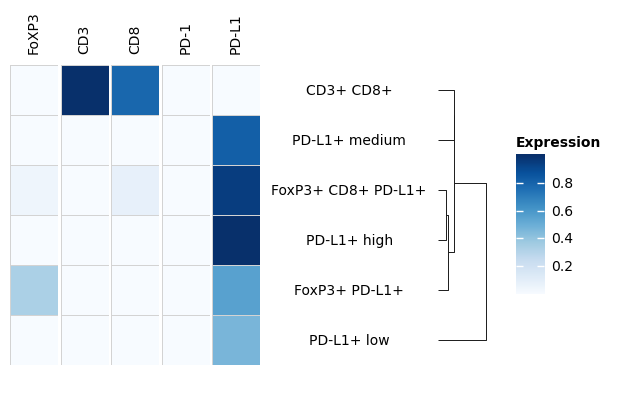

In [149]:
h, w = agg_exp1.shape

m = ma.Heatmap(
    agg_exp1,
    height=h / 2,
    width=w / 2,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",
)
m.add_right(mp.Labels(agg1.obs["louvain2"], align="center"), pad=0.1)


m.add_top(mp.Labels(markers), pad=0.1)


m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))


m.add_left(mp.Numbers(agg_cell_counts1, color="#EEB76B", label="Cell Count"))
'''
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

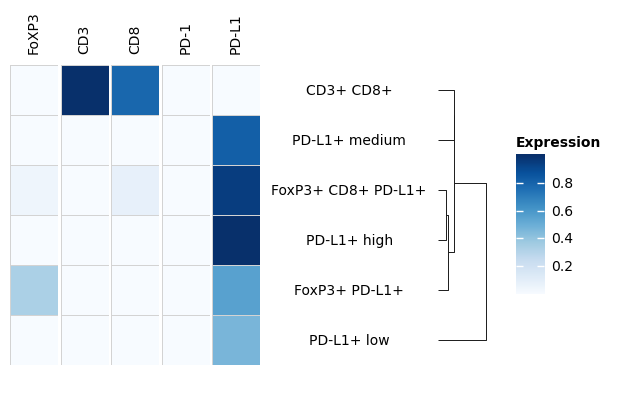

In [155]:
h, w = agg_exp1.shape

m = ma.Heatmap(
    agg_exp1,
    height=h / 2,
    width=w / 2,
    cmap="Blues",
    linewidth=0.5,
    linecolor="lightgray",
    label="Expression",vmax=1,
)
m.add_right(mp.Labels(agg1.obs["louvain2"], align="center"), pad=0.1)


m.add_top(mp.Labels(markers), pad=0.1)


m.group_cols(cells, order=uni_cells)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))


m.add_left(mp.Numbers(agg_cell_counts1, color="#EEB76B", label="Cell Count"))
'''
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

In [150]:
agg_cell_counts1= adata.obs["louvain2"].value_counts().to_numpy()

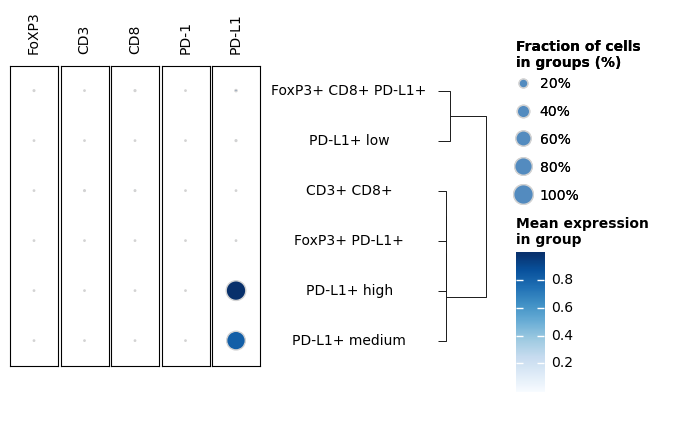

In [151]:
size = agg_count1 / agg_cell_counts1[:, np.newaxis]
m = ma.SizedHeatmap(
    size=size,
    color=agg_exp1,
    cluster_data=size,
    height=h / 2,
    width=w / 2,
    edgecolor="lightgray",
    cmap="Blues",
    size_legend_kws=dict(
        colors="#538bbf",
        title="Fraction of cells\nin groups (%)",
        labels=["20%", "40%", "60%", "80%", "100%"],
        show_at=[0.2, 0.4, 0.6, 0.8, 1.0],
    ),
    color_legend_kws=dict(title="Mean expression\nin group"),
)


m.add_top(mp.Labels(markers), pad=0.1)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.group_cols(cells, order=uni_cells)

m.add_right(mp.Labels(agg1.obs["louvain2"], align="center"), pad=0.1)
'''
m.add_left(
    mp.Numbers(agg_cell_counts1, color="#EEB76B", label="Cell Count"), size=0.5, pad=0.1
)
'''
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

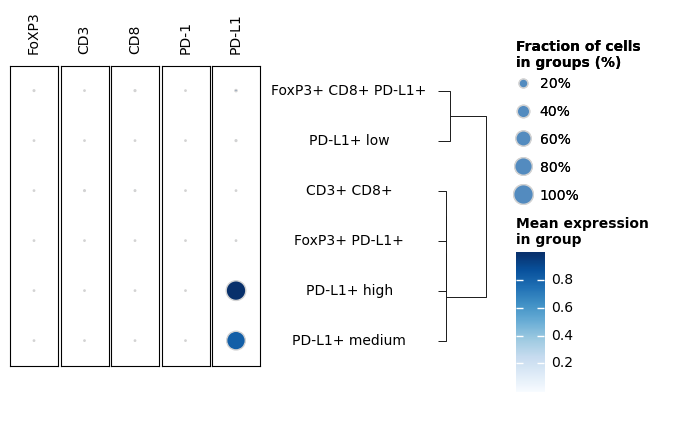

In [156]:
size = agg_count1 / agg_cell_counts1[:, np.newaxis]
m = ma.SizedHeatmap(
    size=size,
    color=agg_exp1,
    cluster_data=size,
    height=h / 2,
    width=w / 2,
    edgecolor="lightgray",
    cmap="Blues",
    size_legend_kws=dict(
        colors="#538bbf",
        title="Fraction of cells\nin groups (%)",
        labels=["20%", "40%", "60%", "80%", "100%"],
        show_at=[0.2, 0.4, 0.6, 0.8, 1.0],
    ),
    color_legend_kws=dict(title="Mean expression\nin group"),vmax=1,
)


m.add_top(mp.Labels(markers), pad=0.1)
'''
m.add_top(mp.Chunk(uni_cells, fill_colors=cell_colors, rotation=90))
'''
m.group_cols(cells, order=uni_cells)

m.add_right(mp.Labels(agg1.obs["louvain2"], align="center"), pad=0.1)
'''
m.add_left(
    mp.Numbers(agg_cell_counts1, color="#EEB76B", label="Cell Count"), size=0.5, pad=0.1
)
'''
m.add_dendrogram("right", pad=0.1)
m.add_legends()

m.render()

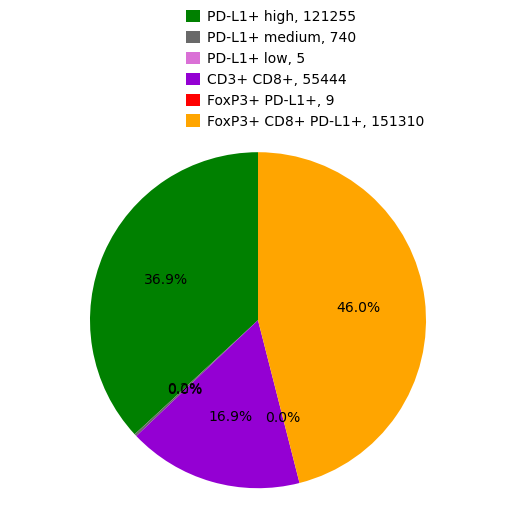

In [154]:
import matplotlib.pyplot as plt
labels = cell_classes#['dogs','cats','birds','fish']
sizes = np.array(col_len).flatten() #[34, 24,18,13]
c= ["green","dimgray","orchid","darkviolet",
              "red", "orange"]
pie = plt.pie(sizes,autopct='%1.1f%%', startangle=90, colors=c)
plt.axis('equal')
plt.legend( loc = 'right', labels=labels)

labels = [f'{l}, {s:0.0f}' for l, s in zip(labels, sizes)]
plt.legend(bbox_to_anchor=(0.85, 1), loc=4, labels=labels)


plt.show()

In [157]:
## plotting the response group spread across these new clusters.

In [158]:
np.unique(cluster_asgn2, return_counts=True)

(array([0, 1, 2, 3, 4, 5]),
 array([121255,    740,      5,  55444,      9, 151310]))

In [186]:
# 19 response
#PR = 0, SD =2, PD=1
pr_list_n = []
pd_list_n = []
sd_list_n = []
tot_cells = count_matrix.shape[0]
# get the rows for sd, pd, pr
unique_ts, counts_ts = np.unique(count_matrix[:,19], return_counts=True)
print(unique_ts)
pr = np.array(np.where(np.array(count_matrix[:,19])==unique_ts[0])).flatten()
pd = np.array(np.where(np.array(count_matrix[:,19])==unique_ts[1])).flatten()
sd = np.array(np.where(np.array(count_matrix[:,19])==unique_ts[2])).flatten()

#get the rows with response (3 of them ) for PDL1+ high
f_rows = np.array(np.where(np.array(cluster_asgn2==0))).flatten()
pr_f = np.intersect1d(pr,f_rows)
pr_list_n.append(pr_f.shape[0]*100/pr.shape[0])
pd_f = np.intersect1d(pd,f_rows)
pd_list_n.append(pd_f.shape[0]*100/pd.shape[0])
sd_f = np.intersect1d(sd,f_rows)
sd_list_n.append(sd_f.shape[0]*100/sd.shape[0])

#get the rows with response (3 of them ) for medium PDL1+
f_rows = np.array(np.where(np.array(cluster_asgn2==1))).flatten()
pr_f = np.intersect1d(pr,f_rows)
pr_list_n.append(pr_f.shape[0]*100/pr.shape[0])
pd_f = np.intersect1d(pd,f_rows)
pd_list_n.append(pd_f.shape[0]*100/pd.shape[0])
sd_f = np.intersect1d(sd,f_rows)
sd_list_n.append(sd_f.shape[0]*100/sd.shape[0])

#get the rows with response (3 of them ) for pdl1 low
f_rows = np.array(np.where(np.array(cluster_asgn2==2))).flatten()
pr_f = np.intersect1d(pr,f_rows)
pr_list_n.append(pr_f.shape[0]*100/pr.shape[0])
pd_f = np.intersect1d(pd,f_rows)
pd_list_n.append(pd_f.shape[0]*100/pd.shape[0])
sd_f = np.intersect1d(sd,f_rows)
sd_list_n.append(sd_f.shape[0]*100/sd.shape[0])

#get the rows with response (3 of them ) for cd3 cd8
f_rows = np.array(np.where(np.array(cluster_asgn2==3))).flatten()
pr_f = np.intersect1d(pr,f_rows)
pr_list_n.append(pr_f.shape[0]*100/pr.shape[0])
pd_f = np.intersect1d(pd,f_rows)
pd_list_n.append(pd_f.shape[0]*100/pd.shape[0])
sd_f = np.intersect1d(sd,f_rows)
sd_list_n.append(sd_f.shape[0]*100/sd.shape[0])

#get the rows with response (3 of them ) for FoX+PDL1
f_rows = np.array(np.where(np.array(cluster_asgn2==4))).flatten()
pr_f = np.intersect1d(pr,f_rows)
pr_list_n.append(pr_f.shape[0]*100/pr.shape[0])
pd_f = np.intersect1d(pd,f_rows)
pd_list_n.append(pd_f.shape[0]*100/pd.shape[0])
sd_f = np.intersect1d(sd,f_rows)
sd_list_n.append(sd_f.shape[0]*100/sd.shape[0])

#get the rows with response (3 of them ) for FoX+PDL1+CD8+
f_rows = np.array(np.where(np.array(cluster_asgn2==5))).flatten()
pr_f = np.intersect1d(pr,f_rows)
pr_list_n.append(pr_f.shape[0]*100/pr.shape[0])
pd_f = np.intersect1d(pd,f_rows)
pd_list_n.append(pd_f.shape[0]*100/pd.shape[0])
sd_f = np.intersect1d(sd,f_rows)
sd_list_n.append(sd_f.shape[0]*100/sd.shape[0])



[0. 1. 2.]


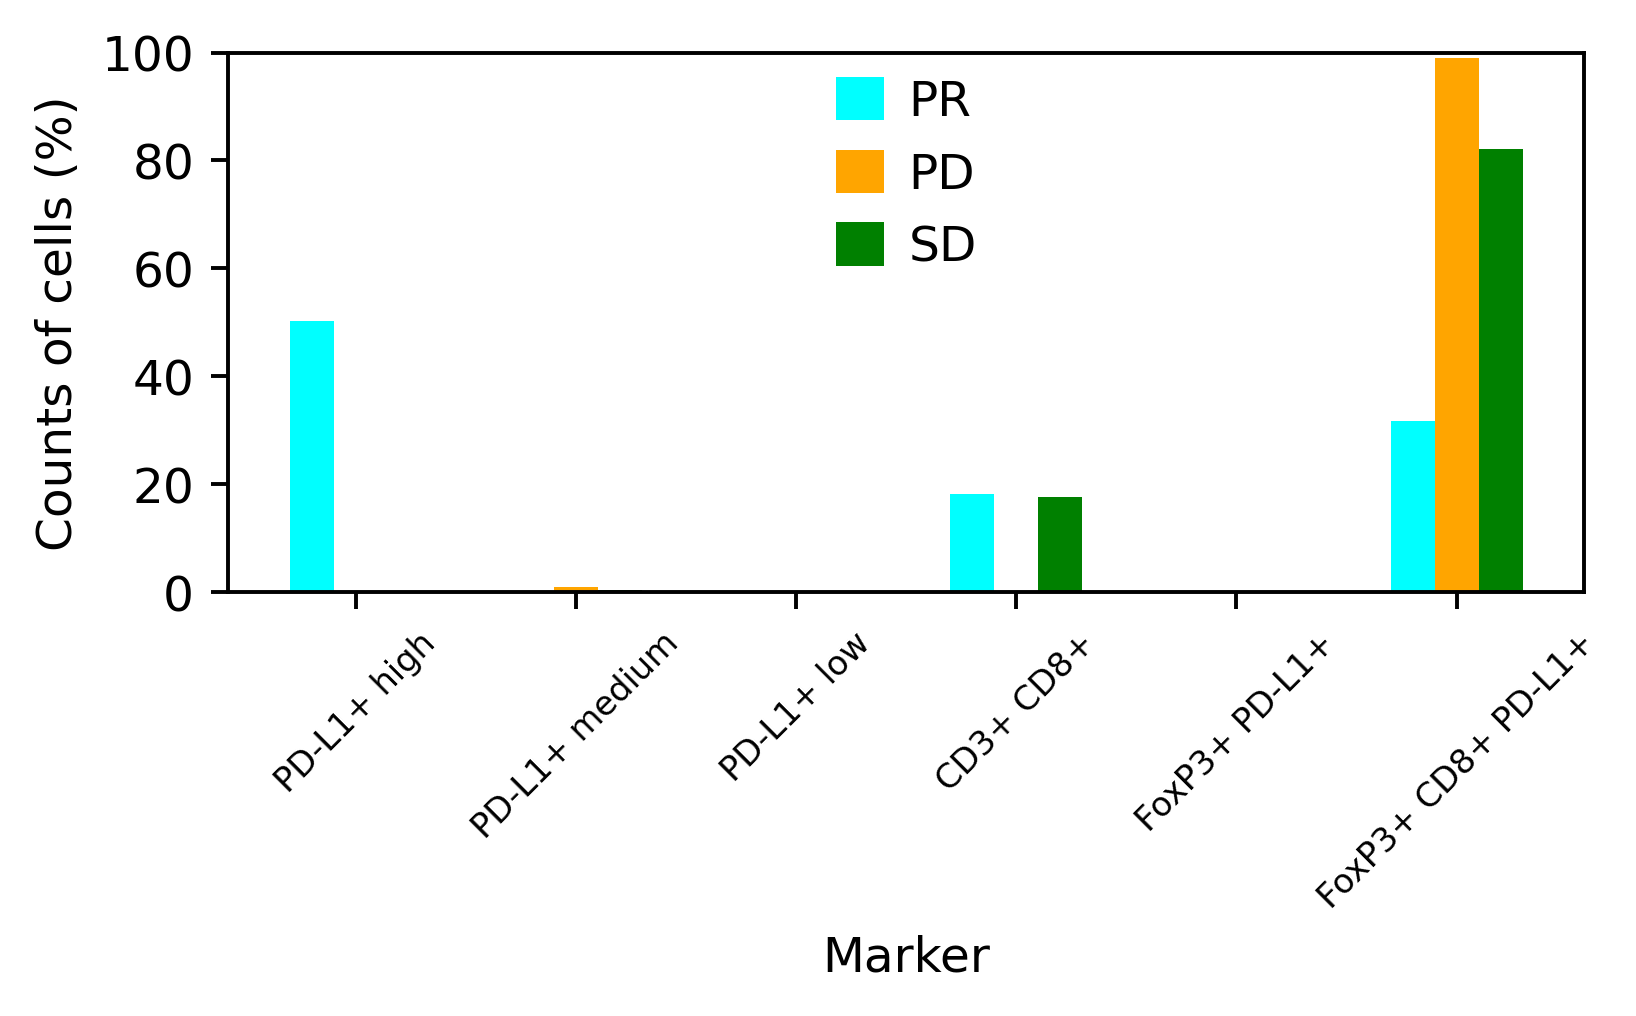

In [209]:
# importing package 
import matplotlib.pyplot as plt 
import numpy as np 

plt.figure(figsize=(5,2), dpi=350)
# create data 
x = np.arange(6) 
y1 = pr_list_n
y2 = pd_list_n
y3 = sd_list_n
width = 0.2
  
# plot data in grouped manner of bar type 
plt.bar(x-0.2, y1, width, color='cyan') 
plt.bar(x, y2, width, color='orange') 
plt.bar(x+0.2, y3, width, color='green') 
plt.xticks(x, cell_classes,rotation=45,fontsize='x-small') 
plt.xlabel("Marker") 
plt.ylabel("Counts of cells (%)") 
plt.legend(["PR", "PD", "SD"], loc=9) 
plt.ylim(0,100)
plt.show() 

In [160]:
cell_classes

['PD-L1+ high',
 'PD-L1+ medium',
 'PD-L1+ low',
 'CD3+ CD8+',
 'FoxP3+ PD-L1+',
 'FoxP3+ CD8+ PD-L1+']